In [26]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from hbn.constants import Defaults
from hbn.visualization import visualize

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
# load model output

df = pd.read_csv(os.path.join(Defaults.MODEL_DIR, 'regression-all-phenotypic-models-performance.csv'))

# if scores are +- 2 std from the mean for each model
df = remove_outliers(df, col='explained_variance_score')


In [70]:
# set plotting style
visualize.plotting_style()

<AxesSubplot: xlabel='features', ylabel='explained_variance_score'>

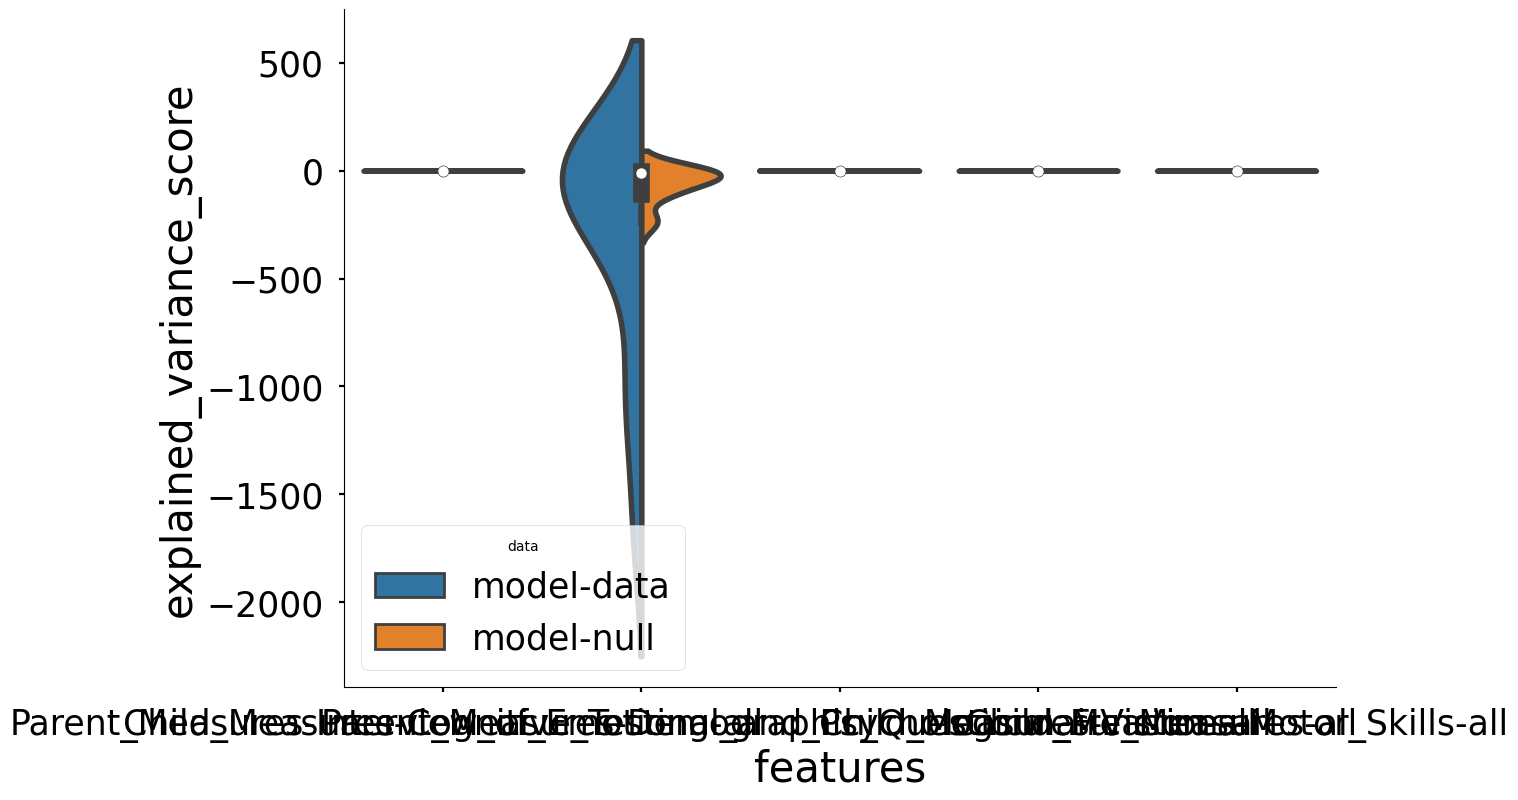

In [72]:
# make violinplots of data output

sns.violinplot(
    x='features', 
    y='explained_variance_score', 
    hue='data', 
    data=df, 
    split=True,  
    hue_order=['model-data', 'model-null'],
    scale='width'
)


In [68]:
def remove_outliers(df, col):   
    # remove outliers (+- 2 std from mean)
    df_model = df.groupby(['model', 'data'])[col].agg(
        {'mean', 'std'}).reset_index().rename(
        {'mean': 'val_mean', 'std': 'val_std'}, axis=1)
    df = df_model.merge(df, on=['model', 'data'])
    df = df[df[col] > df['val_mean'] - 100 * df['val_std']]
    df = df[df[col] < df['val_mean'] + 100 * df['val_std']]
    
    return df
